In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the News Data
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

# Load one Stock File (e.g., NVIDIA) to test
stock_df = pd.read_csv('../data/raw/NVDA.csv')
stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce')

print("Data loaded! News rows:", len(news_df), "| Stock rows:", len(stock_df))
news_df.head()

Data loaded! News rows: 1407328 | Stock rows: 3774


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


C:\Users\Student\AppData\Local\Temp\ipykernel_556\1848419159.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='viridis')


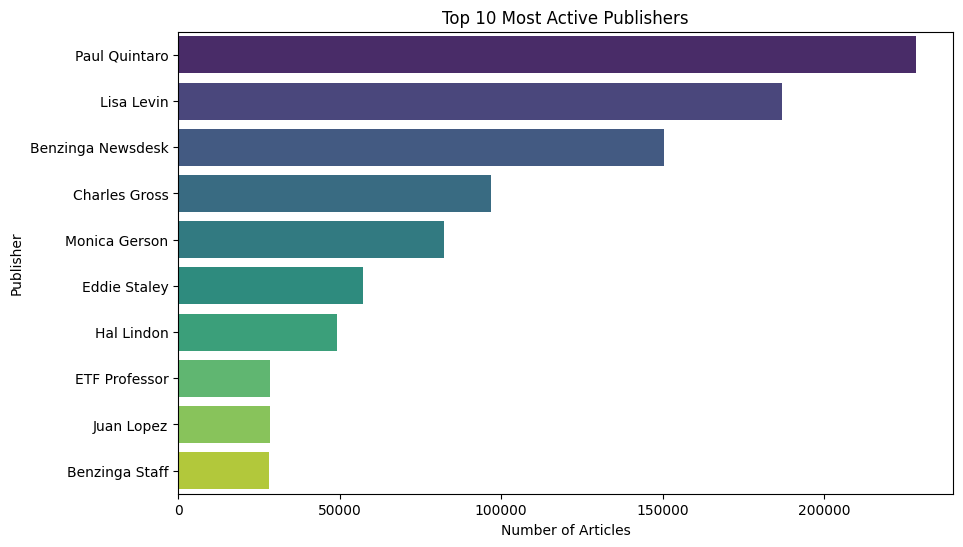

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the top 10 publishers
top_publishers = news_df['publisher'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='viridis')
plt.title('Top 10 Most Active Publishers')
plt.xlabel('Number of Articles')
plt.ylabel('Publisher')
plt.show()

Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


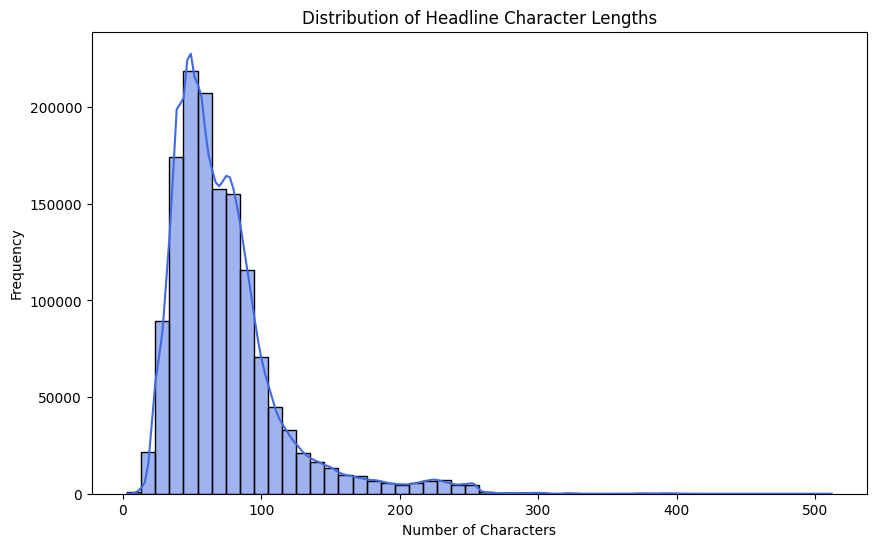

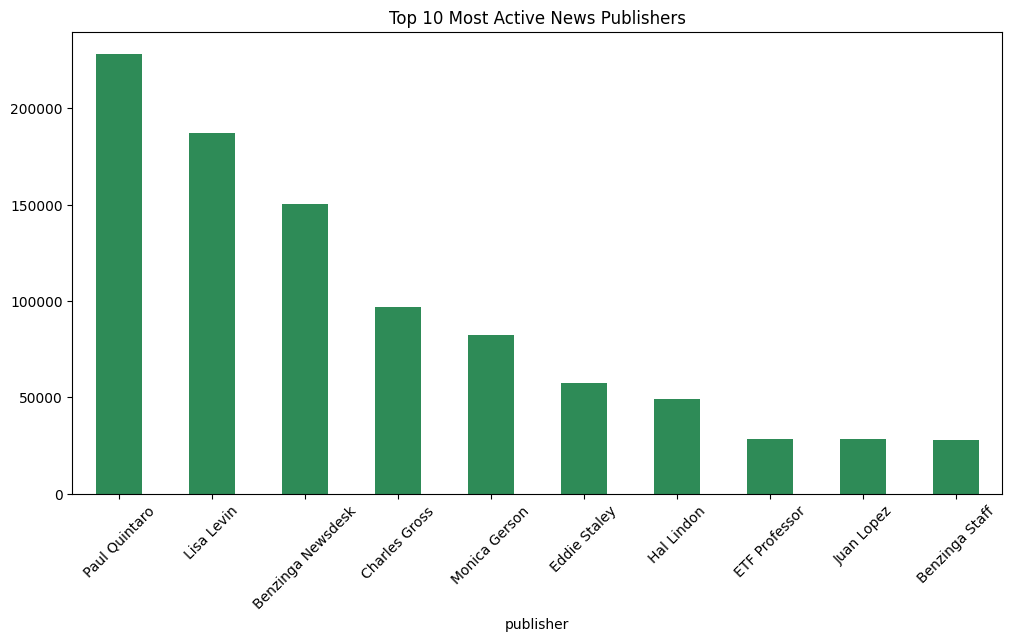

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data (make sure the path matches your 'data/raw' folder)
# We use nrows=100000 just to make it run fast for now!
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# 2. Convert date column to datetime objects
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

# 3. Calculate character counts for headlines
news_df['headline_len'] = news_df['headline'].str.len()

# 4. Display Stats
print("Headline Length Statistics:")
print(news_df['headline_len'].describe())

# 5. Visualize the Distribution
plt.figure(figsize=(10, 6))
sns.histplot(news_df['headline_len'].dropna(), bins=50, kde=True, color='royalblue')
plt.title('Distribution of Headline Character Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

# 6. Count Articles per Publisher
plt.figure(figsize=(12, 6))
news_df['publisher'].value_counts().head(10).plot(kind='bar', color='seagreen')
plt.title('Top 10 Most Active News Publishers')
plt.xticks(rotation=45)
plt.show()

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize TF-IDF Vectorizer
# We look for 2-word phrases (bigrams) and remove common English 'stop words' (like 'the', 'is')
tfidf = TfidfVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)

# 2. Fit and transform the headlines
# .dropna() ensures we don't crash on empty headlines
tfidf_matrix = tfidf.fit_transform(news_df['headline'].dropna())

# 3. Get the feature names (the actual phrases)
feature_names = tfidf.get_feature_names_out()

print("Top 20 Significant Recurring Themes (Bigrams):")
for i, phrase in enumerate(feature_names, 1):
    print(f"{i}. {phrase}")

Top 20 Significant Recurring Themes (Bigrams):
1. 52 week
2. adj eps
3. benzinga upgrades
4. companies trading
5. earnings scheduled
6. initiates coverage
7. market session
8. market update
9. mid day
10. pre market
11. price target
12. q1 eps
13. q2 eps
14. q3 eps
15. raises pt
16. stocks hit
17. stocks moving
18. trading higher
19. trading lower
20. vs est


C:\Users\Student\AppData\Local\Temp\ipykernel_11948\1804491140.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=news_df, palette='magma')


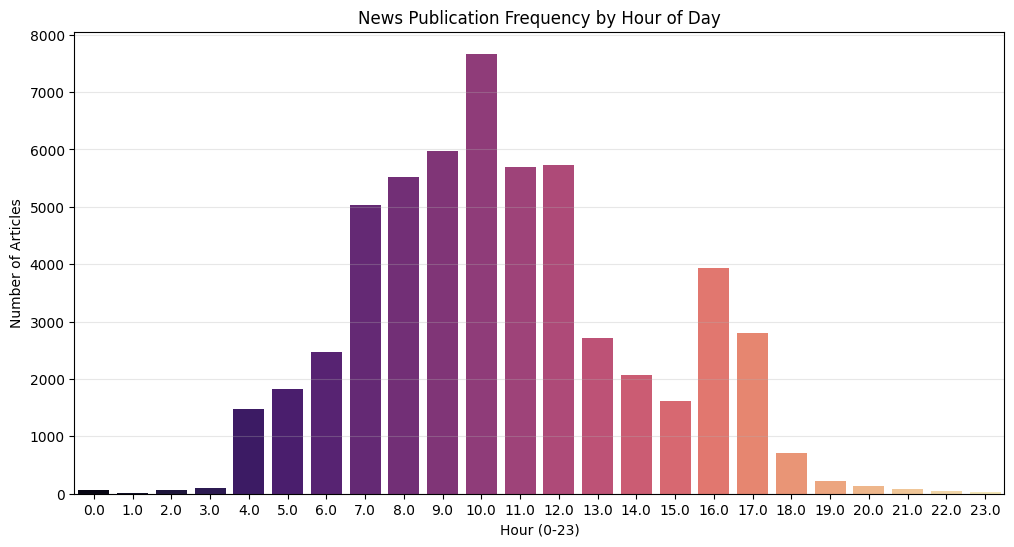

In [4]:
# Extract the hour from the date column
news_df['hour'] = news_df['date'].dt.hour

# Plot the distribution by hour
plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=news_df, palette='magma')
plt.title('News Publication Frequency by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Articles')
plt.grid(axis='y', alpha=0.3)
plt.show()

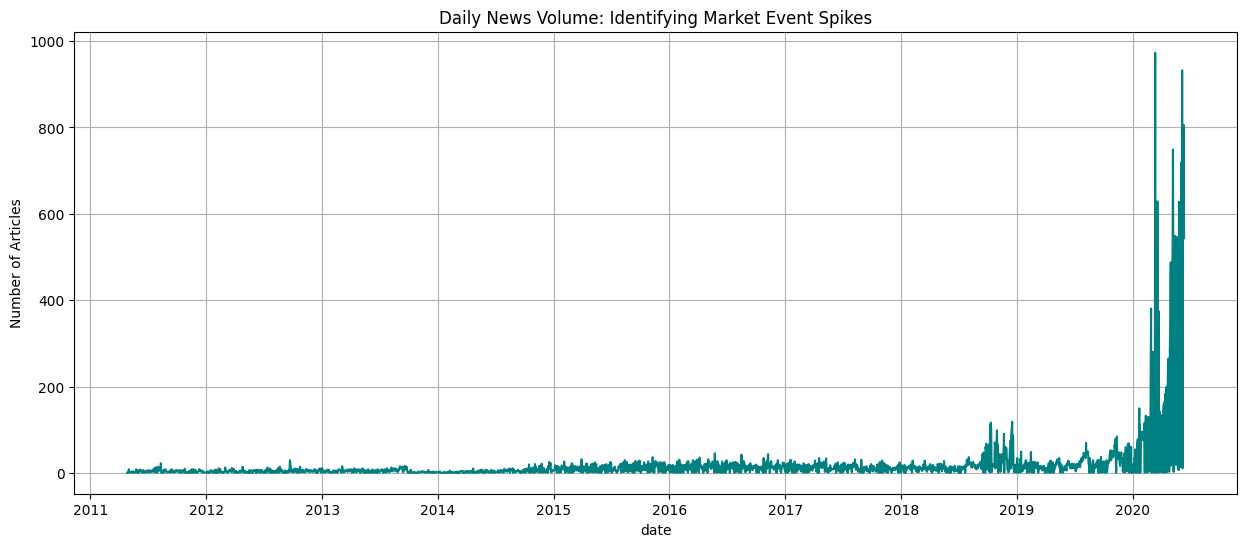

Top 5 Dates with Highest News Volume:
date
2020-03-12    973
2020-06-05    932
2020-06-10    806
2020-06-09    804
2020-06-08    765
dtype: int64


In [5]:
# Group by date and count articles
daily_counts = news_df.groupby(news_df['date'].dt.date).size()

# Plotting the time series
plt.figure(figsize=(15, 6))
daily_counts.plot(color='teal')
plt.title('Daily News Volume: Identifying Market Event Spikes')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()

# Print the top 5 busiest days
print("Top 5 Dates with Highest News Volume:")
print(daily_counts.sort_values(ascending=False).head(5))